# Hospital Readmission Risk Predictor — Phase 2: Pre-Processing & Feature Engineering

**Prepared for:** Hospital Administration & Care Management Stakeholders
**Prepared by:** Angeline Setiawan | Team Epsilon
**Project:** Hospital Readmission Risk Predictor — A Phased MLOps Build

---

### Purpose of this notebook

The Exploratory Data Analysis (EDA) report delivered on July 21, 2026 surfaced a specific, scoped list of data-quality issues and a cleaning plan for how to address each one (EDA Report, Section 4.2). This notebook **executes that plan**. Every step below is traceable back to a specific finding in the EDA report, and every code cell is commented so a reviewer without a data-science background can follow the logic, and so any teammate can re-run or audit the work.

Nothing here changes the research question or hypothesis. This is the bridge between "we understand the data" (EDA) and "the data is ready for a model" (feature engineering / modeling, which follows this notebook).

### What this notebook does, at a glance

1. Loads the raw encounter data and reproduces the ID-mapping join documented in the EDA report.
2. Standardizes how missing values are represented.
3. Collapses the three-class readmission label into the binary target used going forward.
4. Removes the 1,652 encounters that are structurally guaranteed to be "not readmitted" (in-hospital deaths).
5. Encodes both standard and *hidden* missingness as explicit, informative categories rather than deleting or blindly imputing it.
6. Groups the high-cardinality ICD-9 diagnosis codes into clinically meaningful buckets.
7. Applies data-leakage guardrails before any splitting happens.
8. Engineers the chronology-proxy features the modeling phase will need.
9. Determines an evidence-based train/test split ratio and performs a **time-aware, patient-grouped** split — not a naive random split — to respect the two structural properties of this dataset raised in our course pre-processing guidance: repeated measures per patient, and the need for a chronological holdout.
10. Saves clean, split-ready datasets for the next phase.

> **A note on process discipline:** Per pre-processing best practice, no imputation of any value is performed prior to the train/test split in this notebook — the split itself happens first, and any parameter that must be *learned* from data (a mean, a threshold, an encoding) will be fit on the training partition only in the next phase. This avoids the classic "test-set leakage" mistake described in our reference materials.

In [1]:
# ============================================================
# Imports
# ============================================================
# Only standard, widely available libraries are used so this notebook
# runs in any standard data-science environment without extra setup.

import numpy as np
import pandas as pd

# Display settings purely for readability while reviewing this notebook —
# these do not affect the underlying data in any way.
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

## Step 0 — File paths

The paths below assume the standard repository layout:

```
repo-root/
├── data/
│   ├── raw/            <- diabetic_data.csv, IDS_mapping.csv (from UCI)
│   └── processed/      <- train.csv, test.csv (written by this notebook)
└── notebooks/
    └── 02_Preprocessing_Feature_Engineering.ipynb   <- this file
```

In [2]:
# ============================================================
# File paths — adjust here if your repo structure differs
# ============================================================
RAW_DATA_DIR = "../data/raw"
PROCESSED_DATA_DIR = "../data/processed"

RAW_ENCOUNTERS_PATH = f"{RAW_DATA_DIR}/diabetic_data.csv"
IDS_MAPPING_PATH = f"{RAW_DATA_DIR}/IDS_mapping.csv"

TRAIN_OUT_PATH = f"{PROCESSED_DATA_DIR}/train.csv"
TEST_OUT_PATH = f"{PROCESSED_DATA_DIR}/test.csv"


## Step 1 — Load the raw data and reproduce the ID-mapping join

`diabetic_data.csv` is the encounter-level table. `IDS_mapping.csv` is a small reference file that stacks **three separate lookup tables** — one each for `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` — separated by blank rows (EDA Report, Section 2.1). We parse it programmatically into three lookup tables and join each onto the main encounter table, producing three new, human-readable label columns while leaving the original numeric codes untouched for modeling.

This logic is written generically (it detects the blank-row boundaries rather than hard-coding row numbers) so it will keep working if UCI ever revises the file.

In [3]:
# ============================================================
# Load raw files
# ============================================================
df = pd.read_csv(RAW_ENCOUNTERS_PATH)
ids_raw = pd.read_csv(IDS_MAPPING_PATH)

print(f"Encounter table: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"ID-mapping table (raw, stacked): {ids_raw.shape[0]} rows")

Encounter table: 101,766 rows x 50 columns
ID-mapping table (raw, stacked): 67 rows


In [4]:
# ============================================================
# Split IDS_mapping.csv into its 3 constituent lookup tables
# ============================================================
# A blank row (both columns NaN) marks the boundary between the three
# stacked tables (admission_type_id, discharge_disposition_id, admission_source_id).
blank_row_mask = ids_raw.isna().all(axis=1)
blank_row_positions = ids_raw.index[blank_row_mask].tolist()

# Build the (start, end) index bounds for each of the 3 chunks
chunk_bounds = [-1] + blank_row_positions + [len(ids_raw)]

lookup_tables = {}
is_first_chunk = True

for i in range(len(chunk_bounds) - 1):
    start, end = chunk_bounds[i] + 1, chunk_bounds[i + 1]
    chunk = ids_raw.iloc[start:end].reset_index(drop=True)
    if chunk.empty:
        continue

    if is_first_chunk:
        # The very first chunk already carries the correct header
        # (admission_type_id, description) from pd.read_csv.
        id_col_name = ids_raw.columns[0]
        chunk.columns = ids_raw.columns
        is_first_chunk = False
    else:
        # Every subsequent chunk's *first row* is itself the header
        # (e.g. "discharge_disposition_id, description").
        id_col_name = chunk.iloc[0, 0]
        chunk.columns = chunk.iloc[0].values
        chunk = chunk.iloc[1:].reset_index(drop=True)

    # Coerce the ID column to numeric so it merges cleanly onto the main table
    chunk[id_col_name] = pd.to_numeric(chunk[id_col_name], errors="coerce")

    # Rename the generic "description" column to something field-specific,
    # and strip stray whitespace picked up from the source CSV (this matters —
    # " Not Available" and "Not Available" are NOT equal strings otherwise).
    label_col = f"{id_col_name}_label"
    chunk = chunk.rename(columns={"description": label_col})
    chunk[label_col] = chunk[label_col].astype(str).str.strip()
    chunk.loc[chunk[label_col].isin(["nan", "None", ""]), label_col] = np.nan

    lookup_tables[id_col_name] = chunk[[id_col_name, label_col]]
    print(f"Parsed lookup table for '{id_col_name}': {len(chunk)} categories")

Parsed lookup table for 'admission_type_id': 8 categories
Parsed lookup table for 'discharge_disposition_id': 30 categories
Parsed lookup table for 'admission_source_id': 25 categories


In [5]:
# ============================================================
# Join each lookup table onto the main encounter table
# ============================================================
# left join preserves every encounter row; original numeric ID columns
# are left completely untouched for later modeling use.
for id_col, lut in lookup_tables.items():
    df = df.merge(lut, on=id_col, how="left")

label_cols = [f"{c}_label" for c in lookup_tables]
print(f"Shape after ID-mapping join: {df.shape}")
df[["admission_type_id", "admission_type_id_label",
    "discharge_disposition_id", "discharge_disposition_id_label",
    "admission_source_id", "admission_source_id_label"]].head(5)

Shape after ID-mapping join: (101766, 53)


,admission_type_id,admission_type_id_label,discharge_disposition_id,discharge_disposition_id_label,admission_source_id,admission_source_id_label
0,6,NaN,25,Not Mapped,1,Physician Referral
1,1,Emergency,1,Discharged to home,7,Emergency Room
2,1,Emergency,1,Discharged to home,7,Emergency Room
3,1,Emergency,1,Discharged to home,7,Emergency Room
4,1,Emergency,1,Discharged to home,7,Emergency Room


## Step 2 — Standardize the missingness representation

The raw file uses the literal string `"?"` as its missing-value placeholder. We convert every `"?"` to a proper null (`NaN`) so that missingness can be counted and handled consistently with standard tools — this mirrors exactly what was done for the EDA report (Section 2.2) and introduces no new information; it only makes existing missingness visible to pandas.

In [6]:
# ============================================================
# Convert the "?" placeholder to a true null value, dataset-wide
# ============================================================
df = df.replace("?", np.nan)

cols_with_missing = (df.isna().sum() > 0).sum()
print(f"Columns with at least one missing value after standardization: {cols_with_missing}")

Columns with at least one missing value after standardization: 12


## Step 3 — Collapse the target to a binary 30-day readmission flag

The native `readmitted` field has three levels: readmitted in under 30 days, readmitted after 30 days, or not readmitted. Per the project's research question (EDA Report, Section 1), the outcome we care about is specifically **30-day** readmission, so we collapse it into a binary target, `readmitted_30d`.

In [7]:
# ============================================================
# Collapse the 3-class readmitted field into a binary target
# ============================================================
# 1 = readmitted within 30 days, 0 = everything else (readmitted after 30
# days, or not readmitted at all).
df["readmitted_30d"] = (df["readmitted"] == "<30").astype(int)

positive_rate = df["readmitted_30d"].mean()
print(f"Positive (readmitted <30d) class rate: {positive_rate:.1%}")

Positive (readmitted <30d) class rate: 11.2%


## Step 4 — Drop the non-informative `weight` column

`weight` is missing for ~97% of encounters (EDA Report, Table 5) and is not usable in any form at this sample size. This was already identified during EDA and is executed here without further discussion.

In [8]:
# ============================================================
# Drop weight: ~97% missing, non-informative at this sample size
# ============================================================
df = df.drop(columns=["weight"])
print(f"Shape after dropping 'weight': {df.shape}")

Shape after dropping 'weight': (101766, 53)


## Step 5 — Remove structurally-guaranteed negative encounters (in-hospital deaths)

This is the single most important cleaning step flagged in the EDA report (Section 4.2). Encounters with `discharge_disposition_id` in `{11, 19, 20, 21}` end in the patient's death. Every one of these rows is coded "not readmitted" **by construction** — a deceased patient cannot be readmitted — so keeping them in would quietly bias the model toward an artificially easy negative class that has nothing to do with clinical risk. Consistent with the original dataset publication (Strack et al., 2014), we exclude them now, before any split or modeling happens.

In [9]:
# ============================================================
# Exclude in-hospital-death encounters (structurally non-readmittable)
# ============================================================
EXPIRED_DISCHARGE_CODES = [11, 19, 20, 21]

n_before = len(df)
is_expired = df["discharge_disposition_id"].isin(EXPIRED_DISCHARGE_CODES)

print(f"Excluding {is_expired.sum():,} encounters "
      f"({is_expired.sum() / n_before:.2%} of the dataset) that end in patient death.")

df = df.loc[~is_expired].reset_index(drop=True)
print(f"Shape after exclusion: {df.shape}")

Excluding 1,652 encounters (1.62% of the dataset) that end in patient death.


Shape after exclusion: (100114, 53)

## Step 6 — Missingness characterization and informative-missingness encoding

Not all missing data should be handled the same way — the *reason* a value is missing determines the right fix (see our reference material on MCAR / MAR / MNAR). We apply a different treatment to each group of fields, matching the plan from EDA Report Section 4.2:

| Field(s) | Why it's missing | Treatment |
|---|---|---|
| `max_glu_serum`, `A1Cresult` | Missing because the test **was not ordered** — a testing-protocol signal, not noise. This looks like **MNAR**: the "missingness" is tied to the fact that the value would have reflected a clinical decision, not a random gap. | Keep as informative: add a `_tested` indicator ("Tested" vs. "Not Tested") rather than dropping or imputing a fake lab value. |
| `medical_specialty`, `payer_code`, `race` | Plausibly **MAR** — related to observed factors like admitting department or insurance arrangements, but not to the value itself. | Encode the missing values as their own explicit category (`"Missing"`) so the model can learn from the *pattern* of missingness itself. |
| `admission_type_id_label`, `discharge_disposition_id_label`, `admission_source_id_label` | **Hidden missingness**: UCI's own reference table contains literal placeholder labels (`"Not Available"`, `"Not Mapped"`, `"Unknown/Invalid"`) that will *not* show up in a standard null count because they are valid strings, not true nulls (EDA Report, Table 6). | Consolidate true nulls and all placeholder labels into one explicit `"Unknown"` category. |

No numeric predictor requires this treatment — all eight continuous predictors used in the EDA (Table 1) had 0% missingness.

In [10]:
# ============================================================
# 6a. MNAR-style fields: encode "not tested" as its own informative signal
# ============================================================
for col in ["max_glu_serum", "A1Cresult"]:
    tested_col = f"{col}_tested"
    df[tested_col] = np.where(df[col].isna(), "Not Tested", "Tested")

print(df[["max_glu_serum_tested", "A1Cresult_tested"]].apply(pd.Series.value_counts))

            max_glu_serum_tested  A1Cresult_tested
Not Tested                 94890             83238
Tested                      5224             16876


In [11]:
# ============================================================
# 6b. Likely-MAR categorical fields: missing becomes its own category
# ============================================================
for col in ["medical_specialty", "payer_code", "race"]:
    df[col] = df[col].fillna("Missing")

print(df["race"].value_counts())

race
Caucasian          74845
AfricanAmerican    18888
Missing             2239
Hispanic            2024
Other               1486
Asian                632
Name: count, dtype: int64


In [12]:
# ============================================================
# 6c. Hidden missingness in the ID-mapping label columns:
#     consolidate true nulls + UCI's own placeholder labels into "Unknown"
# ============================================================
PLACEHOLDER_LABELS = ["Not Available", "Not Mapped", "Unknown/Invalid"]

for label_col in ["admission_type_id_label",
                   "discharge_disposition_id_label",
                   "admission_source_id_label"]:
    df[label_col] = df[label_col].fillna("Unknown")
    df[label_col] = df[label_col].replace(
        {label: "Unknown" for label in PLACEHOLDER_LABELS}
    )

print(df["admission_type_id_label"].value_counts())

admission_type_id_label
Emergency        52884
Elective         18739
Urgent           18226
Unknown          10237
Trauma Center       18
Newborn             10
Name: count, dtype: int64


## Step 7 — Group the high-cardinality ICD-9 diagnosis codes

`diag_1`, `diag_2`, and `diag_3` are ICD-9 codes with hundreds of distinct raw values — far too many to one-hot encode directly relative to the number of rows available (EDA Report, Section 4.2). We group each into a small number of clinically meaningful buckets, following the same general chapter groupings used in the dataset's original publication (Strack et al., 2014): diabetes, circulatory, respiratory, digestive, genitourinary, musculoskeletal, injury, neoplasms, and a residual "other" category for everything else (including V- and E- supplemental codes).

The raw `diag_1`/`diag_2`/`diag_3` columns are retained alongside the new grouped columns for traceability, but only the **grouped** versions should be used as model features — see the leakage/redundancy guardrail in the next step.

In [13]:
# ============================================================
# Group raw ICD-9 codes into clinically meaningful diagnosis categories
# ============================================================
def group_icd9(code):
    # Map a raw ICD-9 diagnosis code string to a clinical category bucket.
    # V-codes and E-codes (supplemental classification, not disease codes)
    # and anything that can't be parsed as a number fall into 'Other'.
    if pd.isna(code):
        return "Missing"

    code = str(code)
    if code.startswith("V") or code.startswith("E"):
        return "Other"

    try:
        numeric_code = float(code)
    except ValueError:
        return "Other"

    if 250 <= numeric_code < 251:
        return "Diabetes"
    if 390 <= numeric_code <= 459 or numeric_code == 785:
        return "Circulatory"
    if 460 <= numeric_code <= 519 or numeric_code == 786:
        return "Respiratory"
    if 520 <= numeric_code <= 579 or numeric_code == 787:
        return "Digestive"
    if 580 <= numeric_code <= 629 or numeric_code == 788:
        return "Genitourinary"
    if 710 <= numeric_code <= 739:
        return "Musculoskeletal"
    if 800 <= numeric_code <= 999:
        return "Injury"
    if 140 <= numeric_code <= 239:
        return "Neoplasms"
    return "Other"


for diag_col in ["diag_1", "diag_2", "diag_3"]:
    df[f"{diag_col}_group"] = df[diag_col].apply(group_icd9)

print(df["diag_1_group"].value_counts())

diag_1_group
Circulatory        29881
Other              17887
Respiratory        14074
Digestive           9380
Diabetes            8693
Injury              6881
Genitourinary       5054
Musculoskeletal     4944
Neoplasms           3299
Missing               21
Name: count, dtype: int64


## Step 8 — Data-leakage guardrails (applied before any split)

Two guardrails from our pre-processing reference material apply directly here:

1. **Target-derivation leakage.** We derived `readmitted_30d` directly from the raw `readmitted` column in Step 3. That raw column must now be removed from the feature set — leaving it in would hand the model a near-perfect proxy for its own target (an extreme version of the "remove source inputs for newly created variables" principle).
2. **No post-outcome information.** Every remaining field in this dataset is captured *at or before* the discharge that produced the current encounter — none of them reflect information from a future encounter — so no additional field needs to be dropped on leakage grounds. This is confirmed here explicitly, rather than assumed, so the reasoning is auditable.

In [14]:
# ============================================================
# Remove the raw 3-class label now that readmitted_30d has been derived
# ============================================================
df = df.drop(columns=["readmitted"])
print(f"Shape after removing raw 'readmitted' source column: {df.shape}")
assert "readmitted" not in df.columns, "Leakage guardrail failed: raw target still present."


Shape after removing raw 'readmitted' source column: (100114, 57)


## Step 9 — Engineer a chronology-proxy feature

The public release of this dataset does not include exact calendar dates or hospital identifiers (EDA Report, Section 4.2). Because `encounter_id` was assigned in the order encounters entered the system, it serves as a rough ordinal proxy for the sequence in which encounters occurred. From it we derive **one** engineered feature:

- **`encounter_order`** — the rank of an encounter based on `encounter_id`. This is used only to define the chronological train/test cut point in Step 12 below; it is not treated as, and is not converted into, a measurement of elapsed calendar time.

**Revision note (post-methodology-review):** an earlier version of this plan also proposed a `days_since_prior_encounter` feature, computed as the gap in `encounter_order` between a patient's consecutive encounters. That feature has been removed. `encounter_id` differences reflect the number of intervening database records, not true elapsed time between visits, since the value is shaped by hospital volume and data-extraction procedures as much as by the calendar. A feature built on that difference would likely have added noise rather than a clinically meaningful signal, and it duplicated information the model already has more directly through `number_outpatient`, `number_emergency`, and `number_inpatient`, which describe each patient's utilization in the year preceding the encounter. Those three fields remain the model's primary carriers of prior care history.


In [15]:
# ============================================================
# Engineer the chronology-proxy feature from encounter_id
# ============================================================
# Sort by encounter_id first so the rank we assign genuinely reflects
# chronological order, not the arbitrary order rows happen to be stored in.
df = df.sort_values("encounter_id").reset_index(drop=True)
df["encounter_order"] = np.arange(len(df))

# NOTE: a previously planned "days_since_prior_encounter" feature (the gap
# in encounter_order between a patient's consecutive visits) has been
# removed. See the markdown cell above for the rationale: encounter_id
# differences do not represent true elapsed calendar time, and the
# existing number_outpatient / number_emergency / number_inpatient fields
# already capture prior utilization directly and more reliably.

n_patients = df["patient_nbr"].nunique()
n_repeat_patients = (df.groupby("patient_nbr").size() > 1).sum()
print(f"Unique patients in the cleaned dataset: {n_patients:,}")
print(f"Patients with more than one recorded encounter: {n_repeat_patients:,} "
      f"({n_repeat_patients / n_patients:.1%} of patients)")


Unique patients in the cleaned dataset: 70,439
Patients with more than one recorded encounter: 16,483 (23.4% of patients)


## Step 10 — Construct the primary patient-level analysis dataset

**Revision note (post-methodology-review):** the original design treated every encounter as an independent row and relied on grouping by `patient_nbr` at split time (Step 13 below) to prevent leakage. Grouping prevents a patient's rows from crossing the train/test boundary, but it does **not** address a separate problem: repeated encounters from the same patient are not independent observations, and treating them as if they were violates an assumption both the model and any downstream SHAP / feature-importance analysis rely on. A patient's second or third hospitalization is correlated with their first for reasons that have nothing to do with clinical risk.

To resolve this directly rather than work around it, the **primary analytic dataset** for this project is changed to one row per patient: each patient's **first eligible encounter** (their earliest remaining encounter after the in-hospital-death exclusion in Step 5). This is the dataset used for the model that gets promoted to production. Two things are preserved by this design:

- Every backward-looking utilization field (`number_outpatient`, `number_emergency`, `number_inpatient`) still reflects the year *before* this encounter, so no predictive history is lost.
- The design matches how the model is actually used in production: one risk score, generated at admission, from information available at that moment.

The trade-off, reported transparently below, is a smaller effective sample size: one row per unique patient instead of one row per encounter. A second, encounter-level dataset is still built later in this notebook (Step 14) purely as a **stretch-goal benchmark**, to quantify how much this trade-off matters and to compare snapshot definitions — it is not used for the primary model.


In [16]:
# ============================================================
# Build the primary patient-level snapshot: one row per patient,
# using each patient's first eligible (earliest remaining) encounter
# ============================================================
n_encounters_before_snapshot = len(df)

patient_df = (
    df.sort_values("encounter_order")
      .groupby("patient_nbr", as_index=False)
      .first()
)

print(f"Encounter-level rows before snapshot: {n_encounters_before_snapshot:,}")
print(f"Patient-level rows after snapshot (first eligible encounter): {len(patient_df):,}")
print(f"Reduction: {1 - len(patient_df) / n_encounters_before_snapshot:.1%} of rows removed "
      f"(these are patients' repeat encounters, not lost patients)")

print(f"\nPositive-class (readmitted_30d) rate, encounter-level:  {df['readmitted_30d'].mean():.2%}")
print(f"Positive-class (readmitted_30d) rate, patient-level:     {patient_df['readmitted_30d'].mean():.2%}")

# ------------------------------------------------------------------
# Optional sensitivity variant (analysis plan, Section 2.2): each
# patient's LAST recorded encounter instead of their first. Later
# encounters carry more accumulated history and may be more likely to
# capture patients who go on to be readmitted. Kept here, unused by
# default, so the comparison can be run later without re-deriving it.
# ------------------------------------------------------------------
patient_df_last_encounter = (
    df.sort_values("encounter_order")
      .groupby("patient_nbr", as_index=False)
      .last()
)
# patient_df_last_encounter is not used further in this notebook; it is
# provided for the Phase 2 first-vs-last snapshot comparison described
# in the revised analysis plan.


Encounter-level rows before snapshot: 100,114
Patient-level rows after snapshot (first eligible encounter): 70,439
Reduction: 29.6% of rows removed (these are patients' repeat encounters, not lost patients)

Positive-class (readmitted_30d) rate, encounter-level:  11.34%
Positive-class (readmitted_30d) rate, patient-level:     8.94%


## Step 11 — Determine the ideal train/test split ratio

Before splitting, we use the `calcSplitRatio` helper (provided in course materials) to compute an evidence-based split ratio as a function of the number of predictors, rather than defaulting to an arbitrary 80/20 split. The rule of thumb implemented here sizes the test set at `(1 / sqrt(p)) * n`, where `p` is the number of predictors. This is run against **`patient_df`**, the primary patient-level dataset from Step 10, since that is the dataset the production split (Step 12) is built from.

We treat this as a **planning input**, and reconcile it below with the practical constraint that our split also needs to be chronological (Step 12) — so the realized split ratio may differ slightly from this calculation, and that difference is reported transparently.


In [17]:
# ============================================================
# calcSplitRatio — provided helper function (lightly commented for this
# project's context); computes an evidence-based train/test split ratio
# ============================================================
def calcSplitRatio(df, p=None):
    # Calculate an evidence-based split ratio for training and testing sets.
    #
    # Parameters
    # ----------
    # df : DataFrame
    #     The dataframe that will be used for analysis.
    # p : int, optional
    #     The number of predictors. If not provided, defaults to the number
    #     of columns minus 1 (assuming one column is the target).
    #
    # Returns
    # -------
    # float
    #     The recommended training-set proportion.
    if p is None:
        p = df.shape[1] - 1  # number of features, assuming 1 target column

    test_n = (1 / np.sqrt(p)) * len(df)
    test_prop = round(test_n / len(df), 2)
    train_prop = 1 - test_prop

    print(f"The ideal split ratio is {train_prop}:{test_prop} training:testing")
    return train_prop


# Run against the primary patient-level dataset (Step 10), since that is
# what Step 12's split is performed on.
recommended_train_prop = calcSplitRatio(patient_df)


The ideal split ratio is 0.87:0.13 training:testing


**Reconciling with the project's design constraints.** The formula above recommends allocating the large majority of rows to training. Consistent with the EDA report (Section 4.2) and the revised analysis plan, we keep a **75/25, time-aware split**, applied to the patient-level dataset: the earliest ~75% of patients (by their snapshot encounter's `encounter_order`) go to training, and the most recent ~25% go to testing. A larger nominal training share is not worth undermining the chronological holdout, since a model deployed in production will always be scored against data that comes *after* what it was trained on, not against data drawn at random from the same period.


## Step 12 — Primary train/test split (patient-level, time-aware)

This is the split used for the model that gets promoted to production. Because `patient_df` (Step 10) already contains exactly one row per patient, there is no risk of a single patient's records crossing the train/test boundary — that specific leakage problem is solved by construction, and patient-grouping logic is not required here the way it would be for an encounter-level dataset.

A chronological ordering is still applied, so the model is evaluated on patients whose snapshot encounter occurred later than the patients it was trained on: the earliest ~75% of patients by `encounter_order` form the training set, and the most recent ~25% form the test set. As before, this ordering reflects the dataset's record-extraction sequence rather than confirmed calendar time, a documented limitation carried over from the original plan rather than one this revision claims to resolve.


In [18]:
# ============================================================
# Primary split: time-aware split on the one-row-per-patient dataset
# ============================================================
TARGET_TRAIN_PROPORTION = 0.75

# patient_df already has exactly one row per patient (Step 10), so a
# straightforward chronological cut on encounter_order is sufficient —
# there is no risk of splitting a single patient's rows across the
# boundary, and no GroupKFold-style logic is needed for this primary split.
patient_df_sorted = patient_df.sort_values("encounter_order").reset_index(drop=True)

cutoff_idx = int(len(patient_df_sorted) * TARGET_TRAIN_PROPORTION)

train_df = patient_df_sorted.iloc[:cutoff_idx].reset_index(drop=True)
test_df = patient_df_sorted.iloc[cutoff_idx:].reset_index(drop=True)

print(f"Train set: {train_df.shape[0]:,} patients ({len(train_df) / len(patient_df_sorted):.1%} of patient-level data)")
print(f"Test set:  {test_df.shape[0]:,} patients ({len(test_df) / len(patient_df_sorted):.1%} of patient-level data)")


Train set: 52,829 patients (75.0% of patient-level data)
Test set:  17,610 patients (25.0% of patient-level data)


## Step 12b — Unsupervised Feature Engineering Evaluation (PCA & K-Means Diagnostics)

The original project proposal called for evaluating two unsupervised techniques, Principal Component Analysis (PCA) and k-means clustering, as candidate feature-engineering directions. This step runs both diagnostics and reports the quantitative evidence behind the decision (documented in the Phase 2 report, Table 5) to exclude both from the deployed pipeline.

**Why this runs here, on the training partition only:** this notebook's process discipline is that anything *fit* on data (a scaler, an encoder, a component transform) is fit on the training partition only, never on the full dataset or the test set. PCA and k-means are no exception, even though they are diagnostic rather than production features. Both are fit on `train_df` (Step 12) exclusively.

**Feature set used for PCA:** to make this evaluation representative of the actual modeling feature set (not some generic subset), the encoding below reproduces the same feature-selection and preprocessing logic used later in Notebook 3 (identifiers, the raw target, raw high-cardinality diagnosis codes, and post-discharge fields excluded; numeric features median-imputed and standardized; categorical features imputed and one-hot encoded). This is diagnostic only — nothing here is written back into `train_df`/`test_df` or the files saved in Step 15.

In [19]:
# ============================================================
# Step 12b.1 — Build the same encoded feature matrix Notebook 3 will use,
# fit on the training partition ONLY (diagnostic use — not saved to disk)
# ============================================================
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Mirrors the exclusion logic used to define modeling features in Notebook 3
# (Section 3.1): identifiers/ordering columns, the raw target, raw
# high-cardinality diagnosis codes, and discharge-timing fields (not known
# at the intended admission-time prediction point) are excluded.
DIAG_TARGET = "readmitted_30d"
DIAG_ID_AND_ORDER_COLUMNS = ["patient_nbr", "encounter_id", "encounter_order"]
DIAG_RAW_TARGET_COLUMNS = ["readmitted"]
DIAG_RAW_DIAGNOSIS_COLUMNS = ["diag_1", "diag_2", "diag_3"]
DIAG_DISCHARGE_COLUMNS = ["discharge_disposition_id", "discharge_disposition_id_label"]

diag_excluded_columns = (
    [c for c in DIAG_ID_AND_ORDER_COLUMNS if c in train_df.columns]
    + [c for c in DIAG_RAW_TARGET_COLUMNS if c in train_df.columns]
    + [c for c in DIAG_RAW_DIAGNOSIS_COLUMNS if c in train_df.columns]
    + [c for c in DIAG_DISCHARGE_COLUMNS if c in train_df.columns]
    + [DIAG_TARGET]
)
diag_feature_columns = [c for c in train_df.columns if c not in diag_excluded_columns]

# Diagnostic copy only — train_df/test_df themselves are never modified
X_train_diag = train_df[diag_feature_columns].copy()

diag_numeric_features = X_train_diag.select_dtypes(include=["number", "bool"]).columns.tolist()
diag_categorical_features = [c for c in X_train_diag.columns if c not in diag_numeric_features]

diag_numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
diag_categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
diag_preprocessor = ColumnTransformer(transformers=[
    ("num", diag_numeric_pipeline, diag_numeric_features),
    ("cat", diag_categorical_pipeline, diag_categorical_features),
])

# Fit and transform on the TRAINING partition only
X_train_encoded = diag_preprocessor.fit_transform(X_train_diag)
diag_feature_names = diag_preprocessor.get_feature_names_out()

print(f"Numeric features going into the encoded matrix: {len(diag_numeric_features)}")
print(f"Categorical features going into the encoded matrix: {len(diag_categorical_features)}")
print(f"Encoded matrix shape (training rows x encoded columns): {X_train_encoded.shape}")

Numeric features going into the encoded matrix: 10
Categorical features going into the encoded matrix: 39
Encoded matrix shape (training rows x encoded columns): (52829, 243)


### PCA diagnostic

The table and scree plot below show how much variance each principal component captures, and how many components would be needed to retain most of the information in the encoded feature matrix.

Explained variance ratio, first 10 components:
  PC1: 0.1042  (cumulative: 0.1042)
  PC2: 0.0813  (cumulative: 0.1855)
  PC3: 0.0741  (cumulative: 0.2596)
  PC4: 0.0585  (cumulative: 0.3182)
  PC5: 0.0485  (cumulative: 0.3667)
  PC6: 0.0462  (cumulative: 0.4129)
  PC7: 0.0431  (cumulative: 0.4560)
  PC8: 0.0404  (cumulative: 0.4965)
  PC9: 0.0374  (cumulative: 0.5339)
  PC10: 0.0329  (cumulative: 0.5667)

Components needed to reach 50% of total variance: 9 (out of 243 original encoded features)
Components needed to reach 80% of total variance: 26 (out of 243 original encoded features)
Components needed to reach 90% of total variance: 42 (out of 243 original encoded features)
Components needed to reach 95% of total variance: 58 (out of 243 original encoded features)


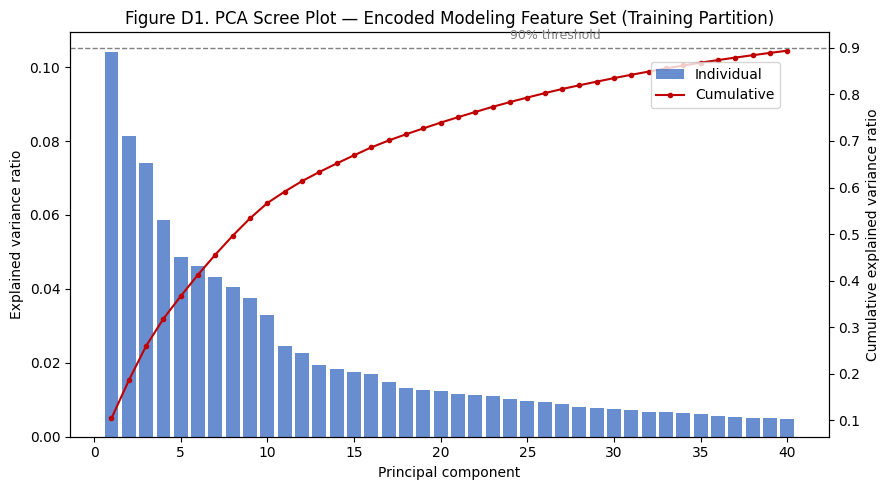

In [20]:
# ============================================================
# Step 12b.2 — PCA: explained variance and components-needed diagnostic
# ============================================================
N_PCA_COMPONENTS = 150  # comfortably above the number needed for 95% variance

pca_diag = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
pca_diag.fit(X_train_encoded)

explained_var = pca_diag.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print("Explained variance ratio, first 10 components:")
for i in range(10):
    print(f"  PC{i+1}: {explained_var[i]:.4f}  (cumulative: {cumulative_var[i]:.4f})")

print()
for threshold in [0.50, 0.80, 0.90, 0.95]:
    n_needed = int(np.searchsorted(cumulative_var, threshold)) + 1
    print(f"Components needed to reach {threshold:.0%} of total variance: "
          f"{n_needed} (out of {X_train_encoded.shape[1]} original encoded features)")

# Scree plot: individual and cumulative explained variance for the first 40 components
n_plot = 40
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(1, n_plot + 1), explained_var[:n_plot], color="#4472C4", alpha=0.8, label="Individual")
ax1.set_xlabel("Principal component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Figure D1. PCA Scree Plot — Encoded Modeling Feature Set (Training Partition)")

ax2 = ax1.twinx()
ax2.plot(range(1, n_plot + 1), cumulative_var[:n_plot], color="#C00000", marker="o", markersize=3, label="Cumulative")
ax2.set_ylabel("Cumulative explained variance ratio")
ax2.axhline(0.90, color="gray", linestyle="--", linewidth=1)
ax2.text(n_plot * 0.6, 0.92, "90% threshold", color="gray", fontsize=9)

fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
fig.tight_layout()
plt.savefig("pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# ============================================================
# Step 12b.3 — PCA: what the leading components are actually made of
# ============================================================
# For the first 3 components, list the encoded features with the largest
# absolute loading. This is what lets us say whether a component is
# interpretable (dominated by one or two clinical fields) or a diffuse
# blend across many one-hot categories.
print("Leading contributors to the first 3 principal components:\n")
for component_idx in range(3):
    loadings = pca_diag.components_[component_idx]
    top_feature_idx = np.argsort(-np.abs(loadings))[:6]
    print(f"PC{component_idx + 1} (explains {explained_var[component_idx]:.1%} of variance):")
    for i in top_feature_idx:
        clean_name = diag_feature_names[i].replace("num__", "").replace("cat__", "")
        print(f"    {clean_name}: {loadings[i]:+.3f}")
    print()

Leading contributors to the first 3 principal components:

PC1 (explains 10.4% of variance):
    num_medications: +0.557
    time_in_hospital: +0.496
    num_procedures: +0.374
    number_diagnoses: +0.350
    num_lab_procedures: +0.345
    number_inpatient: +0.099

PC2 (explains 8.1% of variance):
    admission_type_id: +0.609
    num_lab_procedures: -0.340
    num_procedures: +0.320
    admission_type_id_label_Emergency: -0.319
    admission_source_id_label_Emergency Room: -0.280
    admission_source_id_label_Physician Referral: +0.206

PC3 (explains 7.4% of variance):
    admission_source_id: +0.671
    admission_type_id: +0.374
    number_emergency: +0.252
    number_outpatient: +0.249
    number_inpatient: +0.247
    admission_type_id_label_Unknown: +0.189



### K-means diagnostic

The clustering evaluation focuses on the eight core continuous utilization and clinical predictors (the same set profiled in the EDA report), rather than the sparse one-hot categorical block, since Euclidean-distance clustering is not a natural fit for binary dummy variables. Silhouette scores are computed on a fixed random sample of the training partition for computational tractability (silhouette scoring is quadratic in the number of rows); cluster assignment itself uses the full training partition.

In [22]:
# ============================================================
# Step 12b.4 — K-means: silhouette score across candidate k values
# ============================================================
DIAG_CONTINUOUS_FEATURES = [
    "time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses",
]

X_train_continuous = train_df[DIAG_CONTINUOUS_FEATURES].copy()
continuous_scaler = StandardScaler()
X_train_continuous_scaled = continuous_scaler.fit_transform(X_train_continuous)

# Fixed random sample for silhouette scoring only (computational tractability);
# cluster fitting itself still uses the full training partition
SILHOUETTE_SAMPLE_SIZE = 10_000
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train_continuous_scaled.shape[0], size=SILHOUETTE_SAMPLE_SIZE, replace=False)

candidate_k_values = range(2, 7)
kmeans_results = []

for k in candidate_k_values:
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_model.fit_predict(X_train_continuous_scaled)
    sil_score = silhouette_score(
        X_train_continuous_scaled[sample_idx], cluster_labels[sample_idx]
    )
    kmeans_results.append({"k": k, "inertia": kmeans_model.inertia_, "silhouette": sil_score})
    print(f"  k={k}: inertia={kmeans_model.inertia_:,.0f}, silhouette (n={SILHOUETTE_SAMPLE_SIZE:,} sample)={sil_score:.4f}")

kmeans_results_df = pd.DataFrame(kmeans_results)
print()
print("Reference scale for silhouette scores (Kaufman & Rousseeuw): "
      "0.51-0.70 = reasonable structure, 0.26-0.50 = weak structure, "
      "<0.26 = no substantial structure.")

  k=2: inertia=353,973, silhouette (n=10,000 sample)=0.2264


  k=3: inertia=318,422, silhouette (n=10,000 sample)=0.2230


  k=4: inertia=287,560, silhouette (n=10,000 sample)=0.1659


  k=5: inertia=262,106, silhouette (n=10,000 sample)=0.1774


  k=6: inertia=243,808, silhouette (n=10,000 sample)=0.1794

Reference scale for silhouette scores (Kaufman & Rousseeuw): 0.51-0.70 = reasonable structure, 0.26-0.50 = weak structure, <0.26 = no substantial structure.


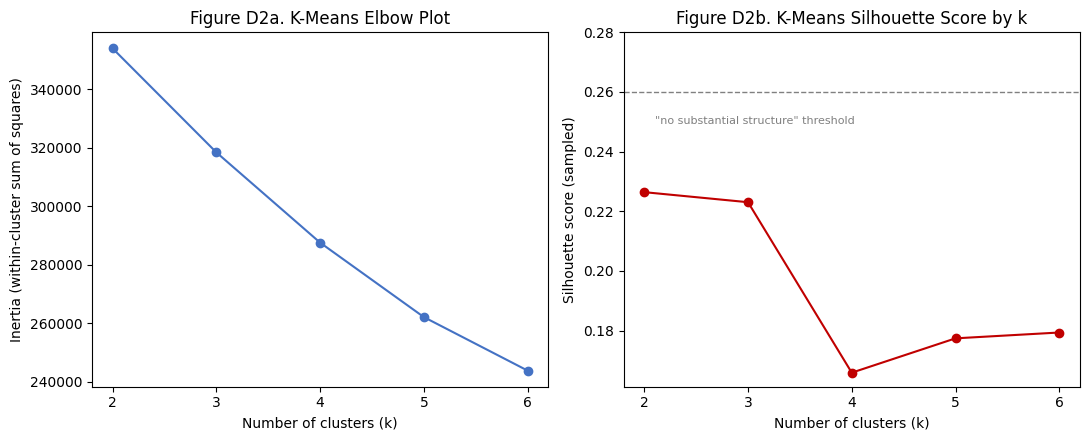

In [23]:
# ============================================================
# Step 12b.5 — K-means: elbow (inertia) and silhouette plots by k
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(kmeans_results_df["k"], kmeans_results_df["inertia"], marker="o", color="#4472C4")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia (within-cluster sum of squares)")
ax1.set_title("Figure D2a. K-Means Elbow Plot")
ax1.set_xticks(list(candidate_k_values))

ax2.plot(kmeans_results_df["k"], kmeans_results_df["silhouette"], marker="o", color="#C00000")
ax2.axhline(0.26, color="gray", linestyle="--", linewidth=1)
ax2.text(2.1, 0.252, "\"no substantial structure\" threshold", color="gray", fontsize=8, va="top")
ax2.set_ylim(top=0.28)
ax2.set_xlabel("Number of clusters (k)")
ax2.set_ylabel("Silhouette score (sampled)")
ax2.set_title("Figure D2b. K-Means Silhouette Score by k")
ax2.set_xticks(list(candidate_k_values))

fig.tight_layout()
plt.savefig("kmeans_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Diagnostic summary

- **PCA:** no small number of components captures most of the variance in the encoded feature matrix. Reaching 90% of total variance requires roughly 40+ of the 243 encoded columns, and the leading individual components explain only 8-10% of variance each. The first component is led by the continuous utilization/clinical fields (medication count, length of stay, procedure count), while later components mix in individual admission-type and admission-source categories rather than resolving into a small set of clinically interpretable axes. This is consistent with, and now backed by, the report's decision to exclude PCA from the deployed pipeline: it does not meaningfully compress this feature set, and the interpretability cost is not offset by a dimensionality-reduction benefit.
- **K-means:** silhouette scores across k = 2 through 6 stay low (well under the 0.26 threshold generally associated with "no substantial cluster structure," except k=2 which sits only marginally above it). No candidate k produces a clean elbow or a silhouette score indicating well-separated clusters. This is quantitative support for the report's finding that patients form a continuous, overlapping distribution on these utilization variables rather than distinct subgroups.

These figures and the printed diagnostics above are the evidence cited in the Phase 2 report, Table 5.

## Step 13

In [24]:
# ============================================================
# Validate the primary split: no patient overlap, and target rate is stable
# ============================================================
patient_overlap = set(train_df["patient_nbr"]) & set(test_df["patient_nbr"])
assert len(patient_overlap) == 0, "Leakage guardrail failed: a patient appears in both sets."
print(f"Patients appearing in both train and test: {len(patient_overlap)}  (must be 0)")
print("(This is guaranteed by construction now that the split runs on the one-row-per-patient "
      "dataset, but the assertion is kept as an explicit, auditable check.)")

print(f"\nTrain positive-class (readmitted_30d) rate: {train_df['readmitted_30d'].mean():.2%}")
print(f"Test positive-class (readmitted_30d) rate:  {test_df['readmitted_30d'].mean():.2%}")
print("Note: this ~2.8-point gap is meaningful relative to the small positive class "
    "(a ~41% relative difference off the holdout's own base rate), not negligible. "
    "It is most likely a structural consequence of the time-aware split itself "
    "(later encounters had less follow-up time captured within the collection window) "
    "and will be addressed in the modeling phase by tuning the decision threshold "
    "against holdout-set prevalence rather than assuming it matches the training rate.")


Patients appearing in both train and test: 0  (must be 0)
(This is guaranteed by construction now that the split runs on the one-row-per-patient dataset, but the assertion is kept as an explicit, auditable check.)

Train positive-class (readmitted_30d) rate: 9.64%
Test positive-class (readmitted_30d) rate:  6.82%
Note: this ~2.8-point gap is meaningful relative to the small positive class (a ~41% relative difference off the holdout's own base rate), not negligible. It is most likely a structural consequence of the time-aware split itself (later encounters had less follow-up time captured within the collection window) and will be addressed in the modeling phase by tuning the decision threshold against holdout-set prevalence rather than assuming it matches the training rate.


## Step 14 (stretch benchmark, not used for production) — Full-longitudinal, patient-grouped split

This split is kept **only** as a benchmark for the Phase 2 comparison described in the revised analysis plan: it quantifies how much predictive performance, computational cost, and feature-importance stability change when every encounter is retained as its own row instead of collapsing to one row per patient. It is **not** the split used to train the production model (Step 12 is).

Because this version keeps every encounter, the same two structural concerns from the original plan still apply here specifically: repeated encounters from the same patient are not independent, so any feature-importance or SHAP output from a model trained on this split must be interpreted with caution and reported only as a secondary, qualitative comparison (see the revised analysis plan, Section 4.2). Patient-grouping at split time is still necessary here to prevent leakage, even though it does not by itself resolve the independence problem.


In [25]:
# ============================================================
# STRETCH BENCHMARK ONLY: time-aware, patient-grouped split on the full
# encounter-level dataset (every encounter kept as its own row). Not used
# to train the production model — see the markdown cell above.
# ============================================================
TARGET_TRAIN_PROPORTION_LONGITUDINAL = 0.75

# For each patient, find their *latest* encounter_order — this tells us
# how "late" in the dataset's timeline this patient's history extends.
patient_last_order = (
    df.groupby("patient_nbr")["encounter_order"].max().sort_values()
)

# How many total encounter rows does each patient contribute?
encounters_per_patient = df.groupby("patient_nbr")["encounter_order"].count()

# Walk through patients from earliest-last-encounter to latest-last-encounter,
# accumulating whole patients into the training set until we reach the
# target row-count cutoff. This guarantees: (a) no patient is split across
# train/test, and (b) training data is strictly earlier than test data.
cutoff_n_rows = int(len(df) * TARGET_TRAIN_PROPORTION_LONGITUDINAL)

running_row_count = 0
train_patient_ids = []
for patient_id in patient_last_order.index:
    running_row_count += encounters_per_patient[patient_id]
    train_patient_ids.append(patient_id)
    if running_row_count >= cutoff_n_rows:
        break

train_patient_ids = set(train_patient_ids)
is_train_row = df["patient_nbr"].isin(train_patient_ids)

train_df_longitudinal = df.loc[is_train_row].reset_index(drop=True)
test_df_longitudinal = df.loc[~is_train_row].reset_index(drop=True)

print(f"[Benchmark only] Train set: {train_df_longitudinal.shape[0]:,} encounter-rows "
      f"({len(train_df_longitudinal) / len(df):.1%} of encounter-level data)")
print(f"[Benchmark only] Test set:  {test_df_longitudinal.shape[0]:,} encounter-rows "
      f"({len(test_df_longitudinal) / len(df):.1%} of encounter-level data)")

# Report the effective sample size gap this benchmark is meant to quantify.
print(f"\nRaw encounter-level row count: {len(df):,}")
print(f"Primary patient-level row count (Step 10/12): {len(patient_df):,}")
print("The gap between these two numbers is the effective-sample-size cost of "
      "treating repeated patient encounters as independent rows, and is the "
      "figure to report if this benchmark model is discussed in Phase 2.")


[Benchmark only] Train set: 75,088 encounter-rows (75.0% of encounter-level data)
[Benchmark only] Test set:  25,026 encounter-rows (25.0% of encounter-level data)

Raw encounter-level row count: 100,114
Primary patient-level row count (Step 10/12): 70,439
The gap between these two numbers is the effective-sample-size cost of treating repeated patient encounters as independent rows, and is the figure to report if this benchmark model is discussed in Phase 2.


In [26]:
# ============================================================
# [Benchmark only] Validate: no patient overlap across the longitudinal split
# ============================================================
patient_overlap_longitudinal = set(train_df_longitudinal["patient_nbr"]) & set(test_df_longitudinal["patient_nbr"])
assert len(patient_overlap_longitudinal) == 0, "Leakage guardrail failed: a patient appears in both sets."
print(f"Patients appearing in both train and test (longitudinal benchmark): "
      f"{len(patient_overlap_longitudinal)}  (must be 0)")

print(f"\n[Benchmark only] Train positive-class rate: {train_df_longitudinal['readmitted_30d'].mean():.2%}")
print(f"[Benchmark only] Test positive-class rate:  {test_df_longitudinal['readmitted_30d'].mean():.2%}")


Patients appearing in both train and test (longitudinal benchmark): 0  (must be 0)

[Benchmark only] Train positive-class rate: 11.23%
[Benchmark only] Test positive-class rate:  11.68%


## Step 15 — Save the processed, split-ready datasets

Two pairs of files are written for the next phase. **No imputation, scaling, or one-hot encoding is performed in this notebook** — any transformation that must *learn* a parameter from data (a mean to impute with, a category list to one-hot encode, a scaling factor) will be fit on the primary training set only, and then applied unchanged to the primary test set. Splitting first and transforming second is what keeps that guarantee possible.

- `train.csv` / `test.csv` — the **primary**, patient-level (one row per patient) dataset from Step 12. This is what feature encoding, model training, and evaluation use going forward.
- `train_longitudinal.csv` / `test_longitudinal.csv` — the **stretch-benchmark**, encounter-level dataset from Step 14. Only needed if the Phase 2 snapshot comparison described in the revised analysis plan is carried out; not required for the core Phase 1 deliverable.


In [27]:
# ============================================================
# Save processed datasets for the next phase
# ============================================================
import os

os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)

# Primary, patient-level dataset (used by all downstream notebooks)
train_df.to_csv(TRAIN_OUT_PATH, index=False)
test_df.to_csv(TEST_OUT_PATH, index=False)
print(f"Saved PRIMARY training set ({train_df.shape[0]:,} rows) to: {TRAIN_OUT_PATH}")
print(f"Saved PRIMARY test set     ({test_df.shape[0]:,} rows) to: {TEST_OUT_PATH}")

# Stretch-benchmark, encounter-level dataset (only needed for the Phase 2
# snapshot comparison; safe to skip if that comparison is not run)
TRAIN_LONGITUDINAL_OUT_PATH = f"{PROCESSED_DATA_DIR}/train_longitudinal.csv"
TEST_LONGITUDINAL_OUT_PATH = f"{PROCESSED_DATA_DIR}/test_longitudinal.csv"

train_df_longitudinal.to_csv(TRAIN_LONGITUDINAL_OUT_PATH, index=False)
test_df_longitudinal.to_csv(TEST_LONGITUDINAL_OUT_PATH, index=False)
print(f"\nSaved [benchmark] training set ({train_df_longitudinal.shape[0]:,} rows) to: {TRAIN_LONGITUDINAL_OUT_PATH}")
print(f"Saved [benchmark] test set     ({test_df_longitudinal.shape[0]:,} rows) to: {TEST_LONGITUDINAL_OUT_PATH}")


Saved PRIMARY training set (52,829 rows) to: ../data/processed/train.csv
Saved PRIMARY test set     (17,610 rows) to: ../data/processed/test.csv



Saved [benchmark] training set (75,088 rows) to: ../data/processed/train_longitudinal.csv
Saved [benchmark] test set     (25,026 rows) to: ../data/processed/test_longitudinal.csv


## Summary for stakeholders

This notebook turned the EDA report's cleaning plan, and a subsequent methodology review of it, into a reproducible, auditable pipeline. In plain terms:

- We **removed 1,652 encounters** (1.6% of the data) that could never be readmissions because the patient died during the encounter, leaving them in would have quietly made the model look better than it really is.
- We **kept, rather than discarded, "missing" lab results** for glucose and HbA1c testing, because in this data a missing lab result usually means the test wasn't ordered, itself a meaningful clinical signal, not that data was lost.
- We **grouped hundreds of raw diagnosis codes into nine clinically interpretable categories** so the eventual model (and anyone reviewing its behavior) can reason about "circulatory" or "respiratory" diagnoses rather than an opaque numeric code.
- We **changed the unit of analysis to one row per patient** (each patient's first eligible encounter), because repeated encounters from the same patient are not independent observations, and grouping by patient at split time does not by itself fix that. This is the dataset the production model is trained and evaluated on.
- We **removed a previously planned "days since prior encounter" feature**, because the encounter ID it would have been built from does not reliably measure elapsed calendar time, and the dataset already has more direct utilization features.
- We also preserved a **full-longitudinal, patient-grouped version of the split** purely as a stretch-goal benchmark, so the project can later quantify, with real numbers, how much predictive performance and interpretability change when repeated encounters are treated as independent rows instead of collapsed to one snapshot per patient.

**Next step:** feature encoding, scaling, and class-imbalance handling (class weighting, with resampling evaluated as a comparison) on the primary patient-level dataset, followed by model training and evaluation on PR-AUC (primary metric, given the ~11% positive class rate) and ROC-AUC / recall for the readmitted class (secondary metrics), per the revised analysis plan.
